# MIND-Small Exploratory Data Analysis

This notebook provides a systematic EDA of the MIND-Small dataset covering:
- `news.tsv` — article content analysis
- `behaviors.tsv` — user behavior analysis
- Joint analysis — click patterns and content differences

**Dataset**: MIND-Small (train split used unless otherwise noted)  
**Random seed**: 42

## 0. Imports & Config

In [12]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter

warnings.filterwarnings('ignore')
np.random.seed(42)

# ── Plot style ────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (10, 4),
                     'axes.titlesize': 13, 'axes.labelsize': 11})
BLUE   = '#4C72B0'
ORANGE = '#DD8452'
GREEN  = '#55A868'
RED    = '#C44E52'

# ── Paths  ────────────────────────────────────────────────────────────────────
# Notebook lives in round1_baselines/ → repo root is one level up
REPO_ROOT  = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_DIR   = os.path.join(REPO_ROOT, 'data')
TRAIN_DIR  = DATA_DIR   
VALID_DIR  = DATA_DIR  
OUTPUT_DIR = os.path.join(os.getcwd(), 'eda_output')
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('REPO_ROOT :', REPO_ROOT)
print('OUTPUT_DIR:', OUTPUT_DIR)
print('train/news.tsv exists?', os.path.exists(os.path.join(TRAIN_DIR, 'news.tsv')))



REPO_ROOT : /Users/ningkezhang/Downloads/2026-MDSH-Submit
OUTPUT_DIR: /Users/ningkezhang/Downloads/2026-MDSH-Submit/round1_baselines/eda_output
train/news.tsv exists? True


## 1. Load Data

In [13]:
NEWS_COLS = ['news_id','category','subcategory','title','abstract',
             'url','title_entities','abstract_entities']
BEH_COLS  = ['impression_id','user_id','time','history','impressions']

news = pd.read_csv(os.path.join(DATA_DIR, 'news.tsv'), sep='\t', header=None, names=NEWS_COLS)
beh  = pd.read_csv(os.path.join(DATA_DIR, 'behaviors.tsv'), sep='\t', header=None, names=BEH_COLS)

# Parse timestamp
beh['time'] = pd.to_datetime(beh['time'], format='%m/%d/%Y %I:%M:%S %p')


print(f'News articles : {len(news):,}')
print(f'Impressions   : {len(beh):,}')
print(f'Unique users             : {beh["user_id"].nunique():,}')
print(f'Date range               : {beh["time"].min().date()} → {beh["time"].max().date()}')

News articles : 42,416
Impressions   : 73,152
Unique users             : 50,000
Date range               : 2019-11-15 → 2019-11-15


---
# Part A — news.tsv Analysis

## A1. Missing Values

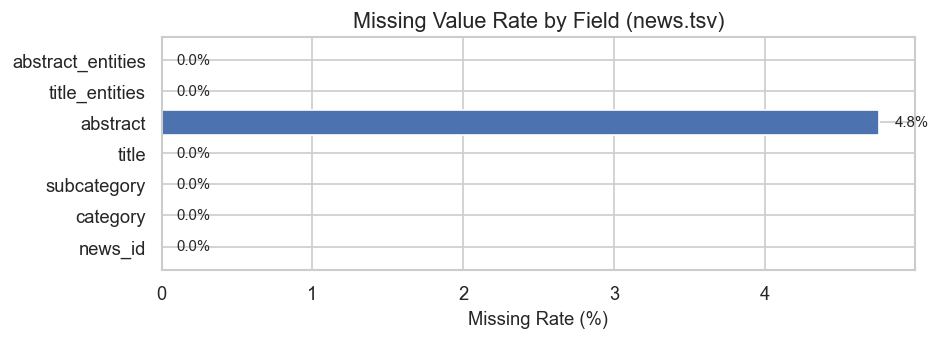

                   Missing Count  Missing %
news_id                        0       0.00
category                       0       0.00
subcategory                    0       0.00
title                          0       0.00
abstract                    2021       4.76
title_entities                 2       0.00
abstract_entities              2       0.00


In [14]:
miss = news[['news_id','category','subcategory','title','abstract',
             'title_entities','abstract_entities']].isnull().sum()
miss_pct = (miss / len(news) * 100).round(2)
miss_df = pd.DataFrame({'Missing Count': miss, 'Missing %': miss_pct})

fig, ax = plt.subplots(figsize=(8, 3))
bars = ax.barh(miss_df.index, miss_df['Missing %'], color=BLUE)
ax.set_xlabel('Missing Rate (%)')
ax.set_title('Missing Value Rate by Field (news.tsv)')
for bar, pct in zip(bars, miss_df['Missing %']):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{pct:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'A1_missing_values.png'))
plt.show()
print(miss_df.to_string())

## A2. Category Distribution

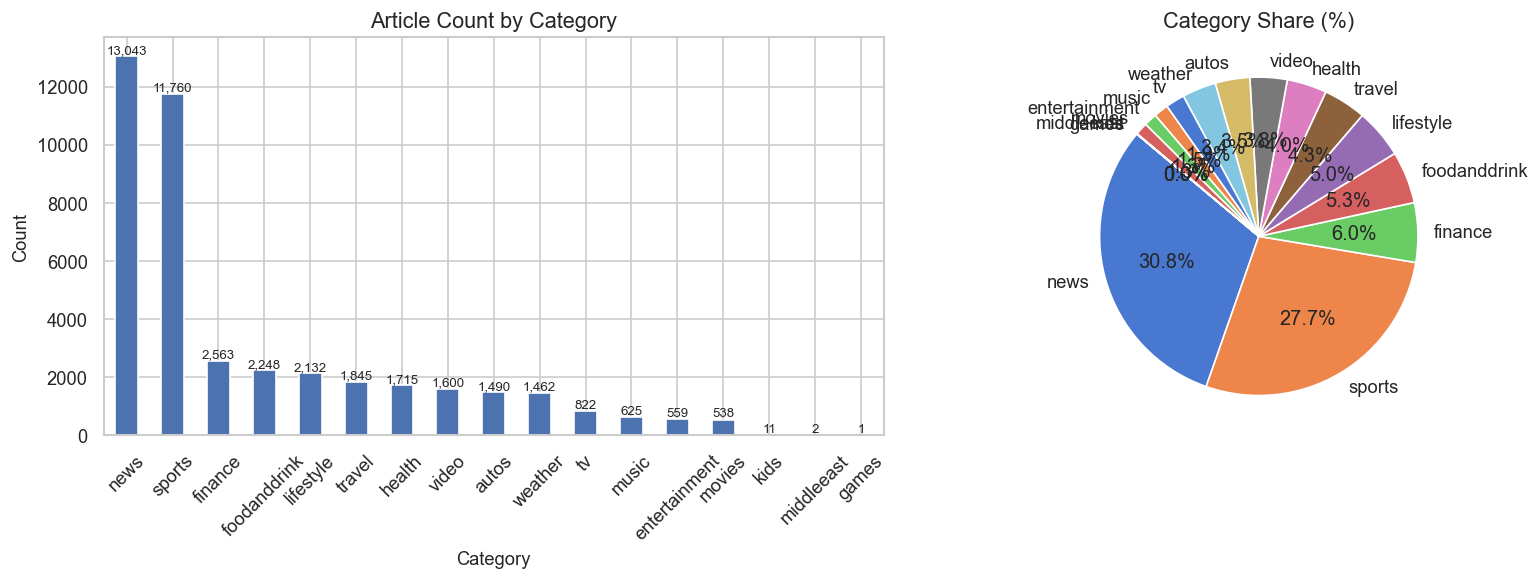

category
news             13043
sports           11760
finance           2563
foodanddrink      2248
lifestyle         2132
travel            1845
health            1715
video             1600
autos             1490
weather           1462
tv                 822
music              625
entertainment      559
movies             538
kids                11
middleeast           2
games                1


In [15]:
cat_counts = news['category'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart — category counts
cat_counts.plot(kind='bar', ax=axes[0], color=BLUE, edgecolor='white')
axes[0].set_title('Article Count by Category')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=8)

# Pie chart
axes[1].pie(cat_counts.values, labels=cat_counts.index,
            autopct='%1.1f%%', startangle=140,
            colors=sns.color_palette('muted', len(cat_counts)))
axes[1].set_title('Category Share (%)')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'A2_category_distribution.png'))
plt.show()
print(cat_counts.to_string())

## A3. Top Subcategories per Category

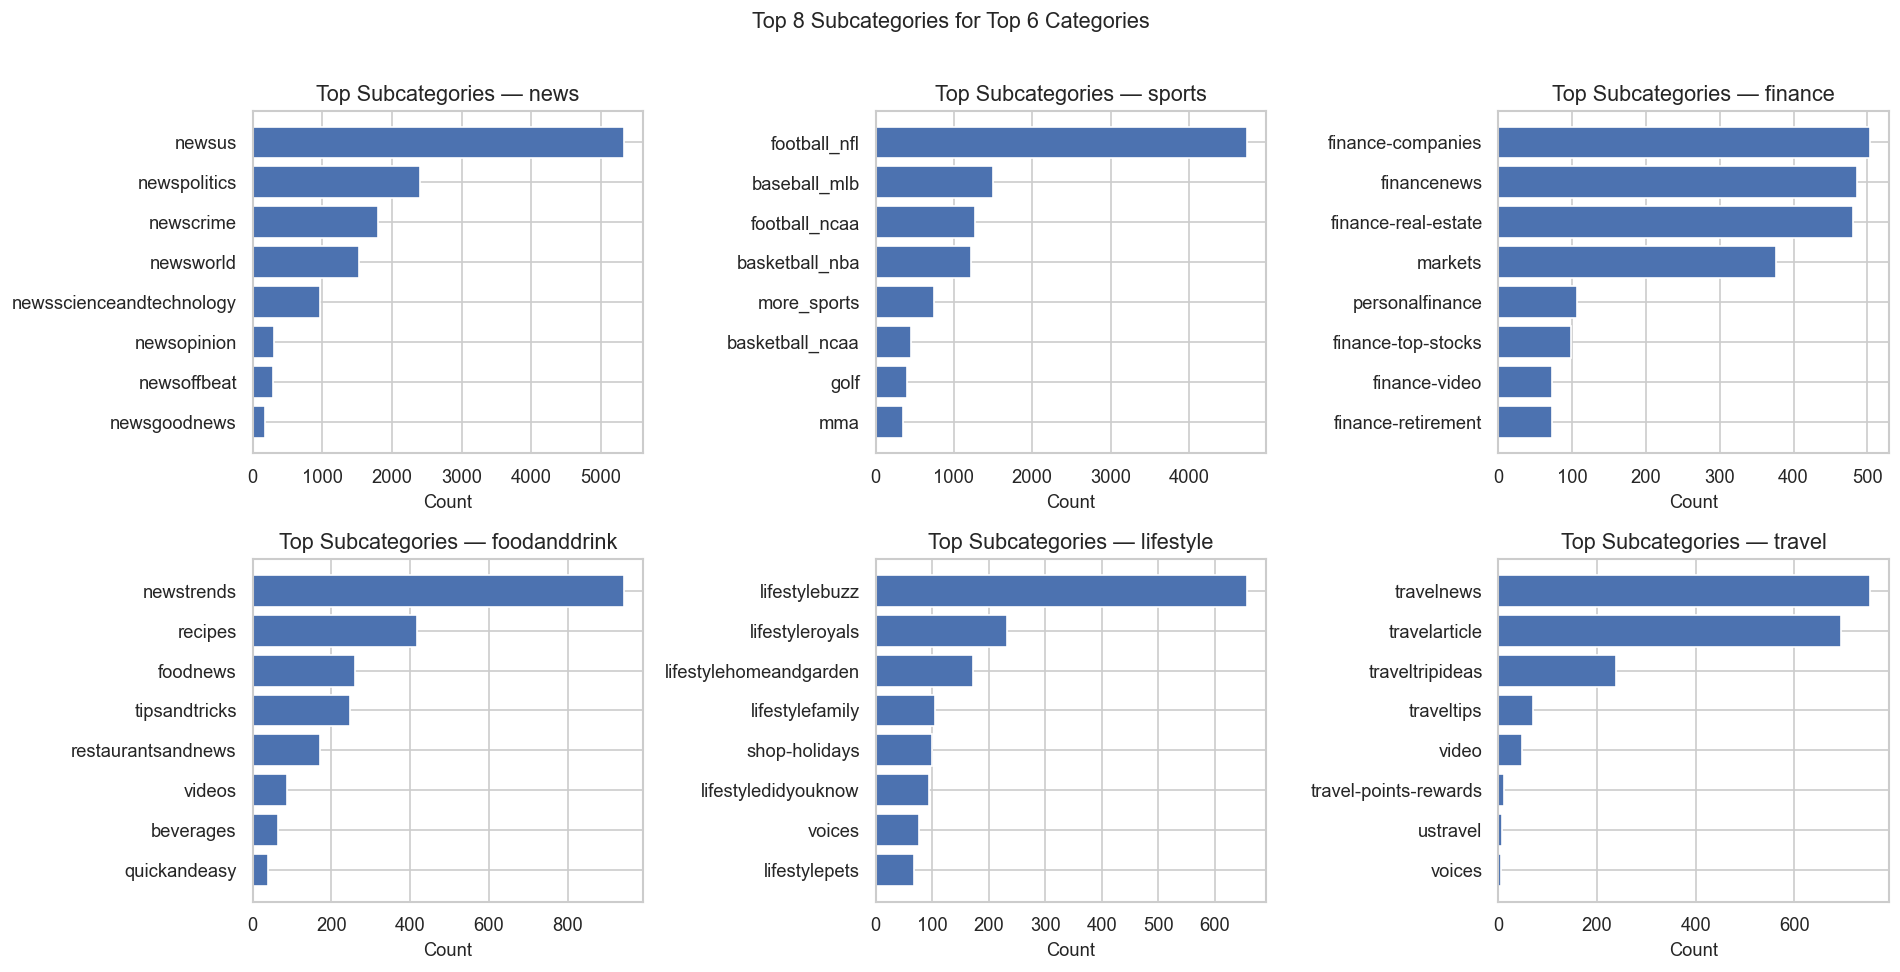

In [16]:
top_cats = cat_counts.head(6).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, cat in enumerate(top_cats):
    sub = news[news['category'] == cat]['subcategory'].value_counts().head(8)
    axes[i].barh(sub.index[::-1], sub.values[::-1], color=BLUE)
    axes[i].set_title(f'Top Subcategories — {cat}')
    axes[i].set_xlabel('Count')

plt.suptitle('Top 8 Subcategories for Top 6 Categories', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'A3_subcategory_top6.png'), bbox_inches='tight')
plt.show()

## A4. Text Length Distribution

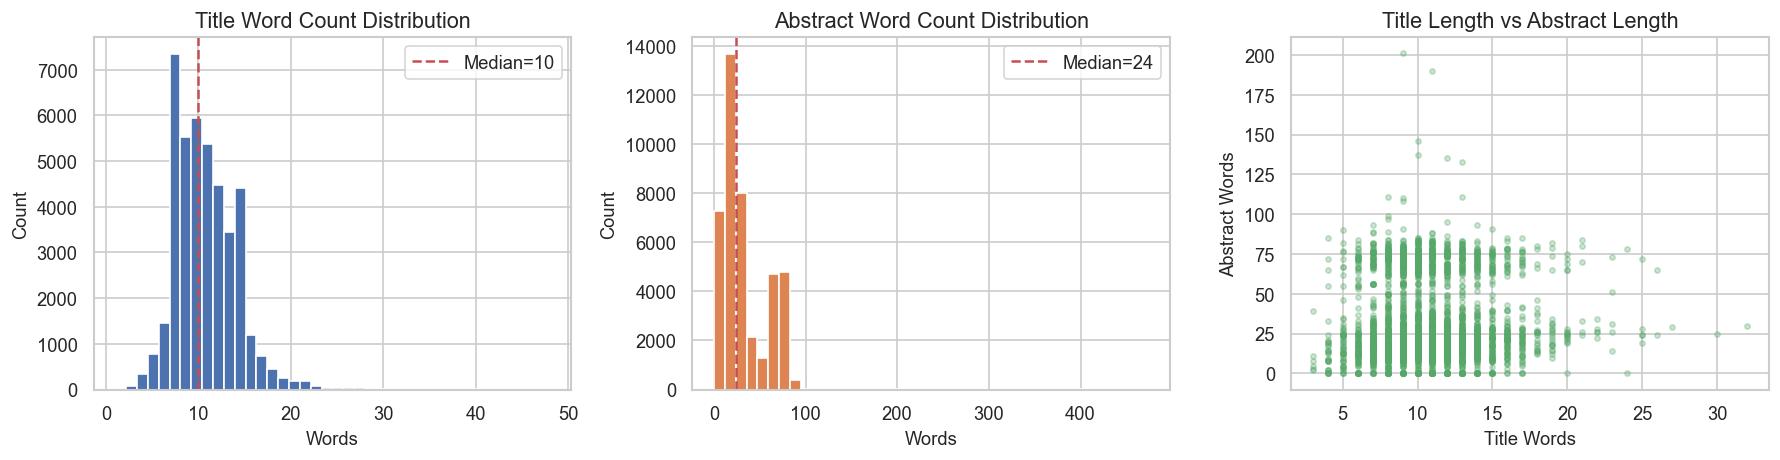

Title length stats:
count    42416.00
mean        10.80
std          3.26
min          1.00
25%          9.00
50%         10.00
75%         13.00
max         48.00

Abstract length stats:
count    42416.00
mean        33.10
std         25.93
min          0.00
25%         15.00
50%         24.00
75%         56.00
max        474.00


In [17]:
news['title_len']    = news['title'].fillna('').apply(lambda x: len(x.split()))
news['abstract_len'] = news['abstract'].fillna('').apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Title length
axes[0].hist(news['title_len'], bins=40, color=BLUE, edgecolor='white')
axes[0].axvline(news['title_len'].median(), color=RED, linestyle='--', label=f'Median={news["title_len"].median():.0f}')
axes[0].set_title('Title Word Count Distribution')
axes[0].set_xlabel('Words')
axes[0].set_ylabel('Count')
axes[0].legend()

# Abstract length
axes[1].hist(news['abstract_len'], bins=40, color=ORANGE, edgecolor='white')
axes[1].axvline(news['abstract_len'].median(), color=RED, linestyle='--', label=f'Median={news["abstract_len"].median():.0f}')
axes[1].set_title('Abstract Word Count Distribution')
axes[1].set_xlabel('Words')
axes[1].set_ylabel('Count')
axes[1].legend()

# Scatter: title vs abstract length
sample = news.sample(min(3000, len(news)), random_state=42)
axes[2].scatter(sample['title_len'], sample['abstract_len'],
                alpha=0.3, s=10, color=GREEN)
axes[2].set_title('Title Length vs Abstract Length')
axes[2].set_xlabel('Title Words')
axes[2].set_ylabel('Abstract Words')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'A4_text_length.png'))
plt.show()

print('Title length stats:')
print(news['title_len'].describe().round(2).to_string())
print('\nAbstract length stats:')
print(news['abstract_len'].describe().round(2).to_string())

## A5. Top Words by Category (TF-IDF)

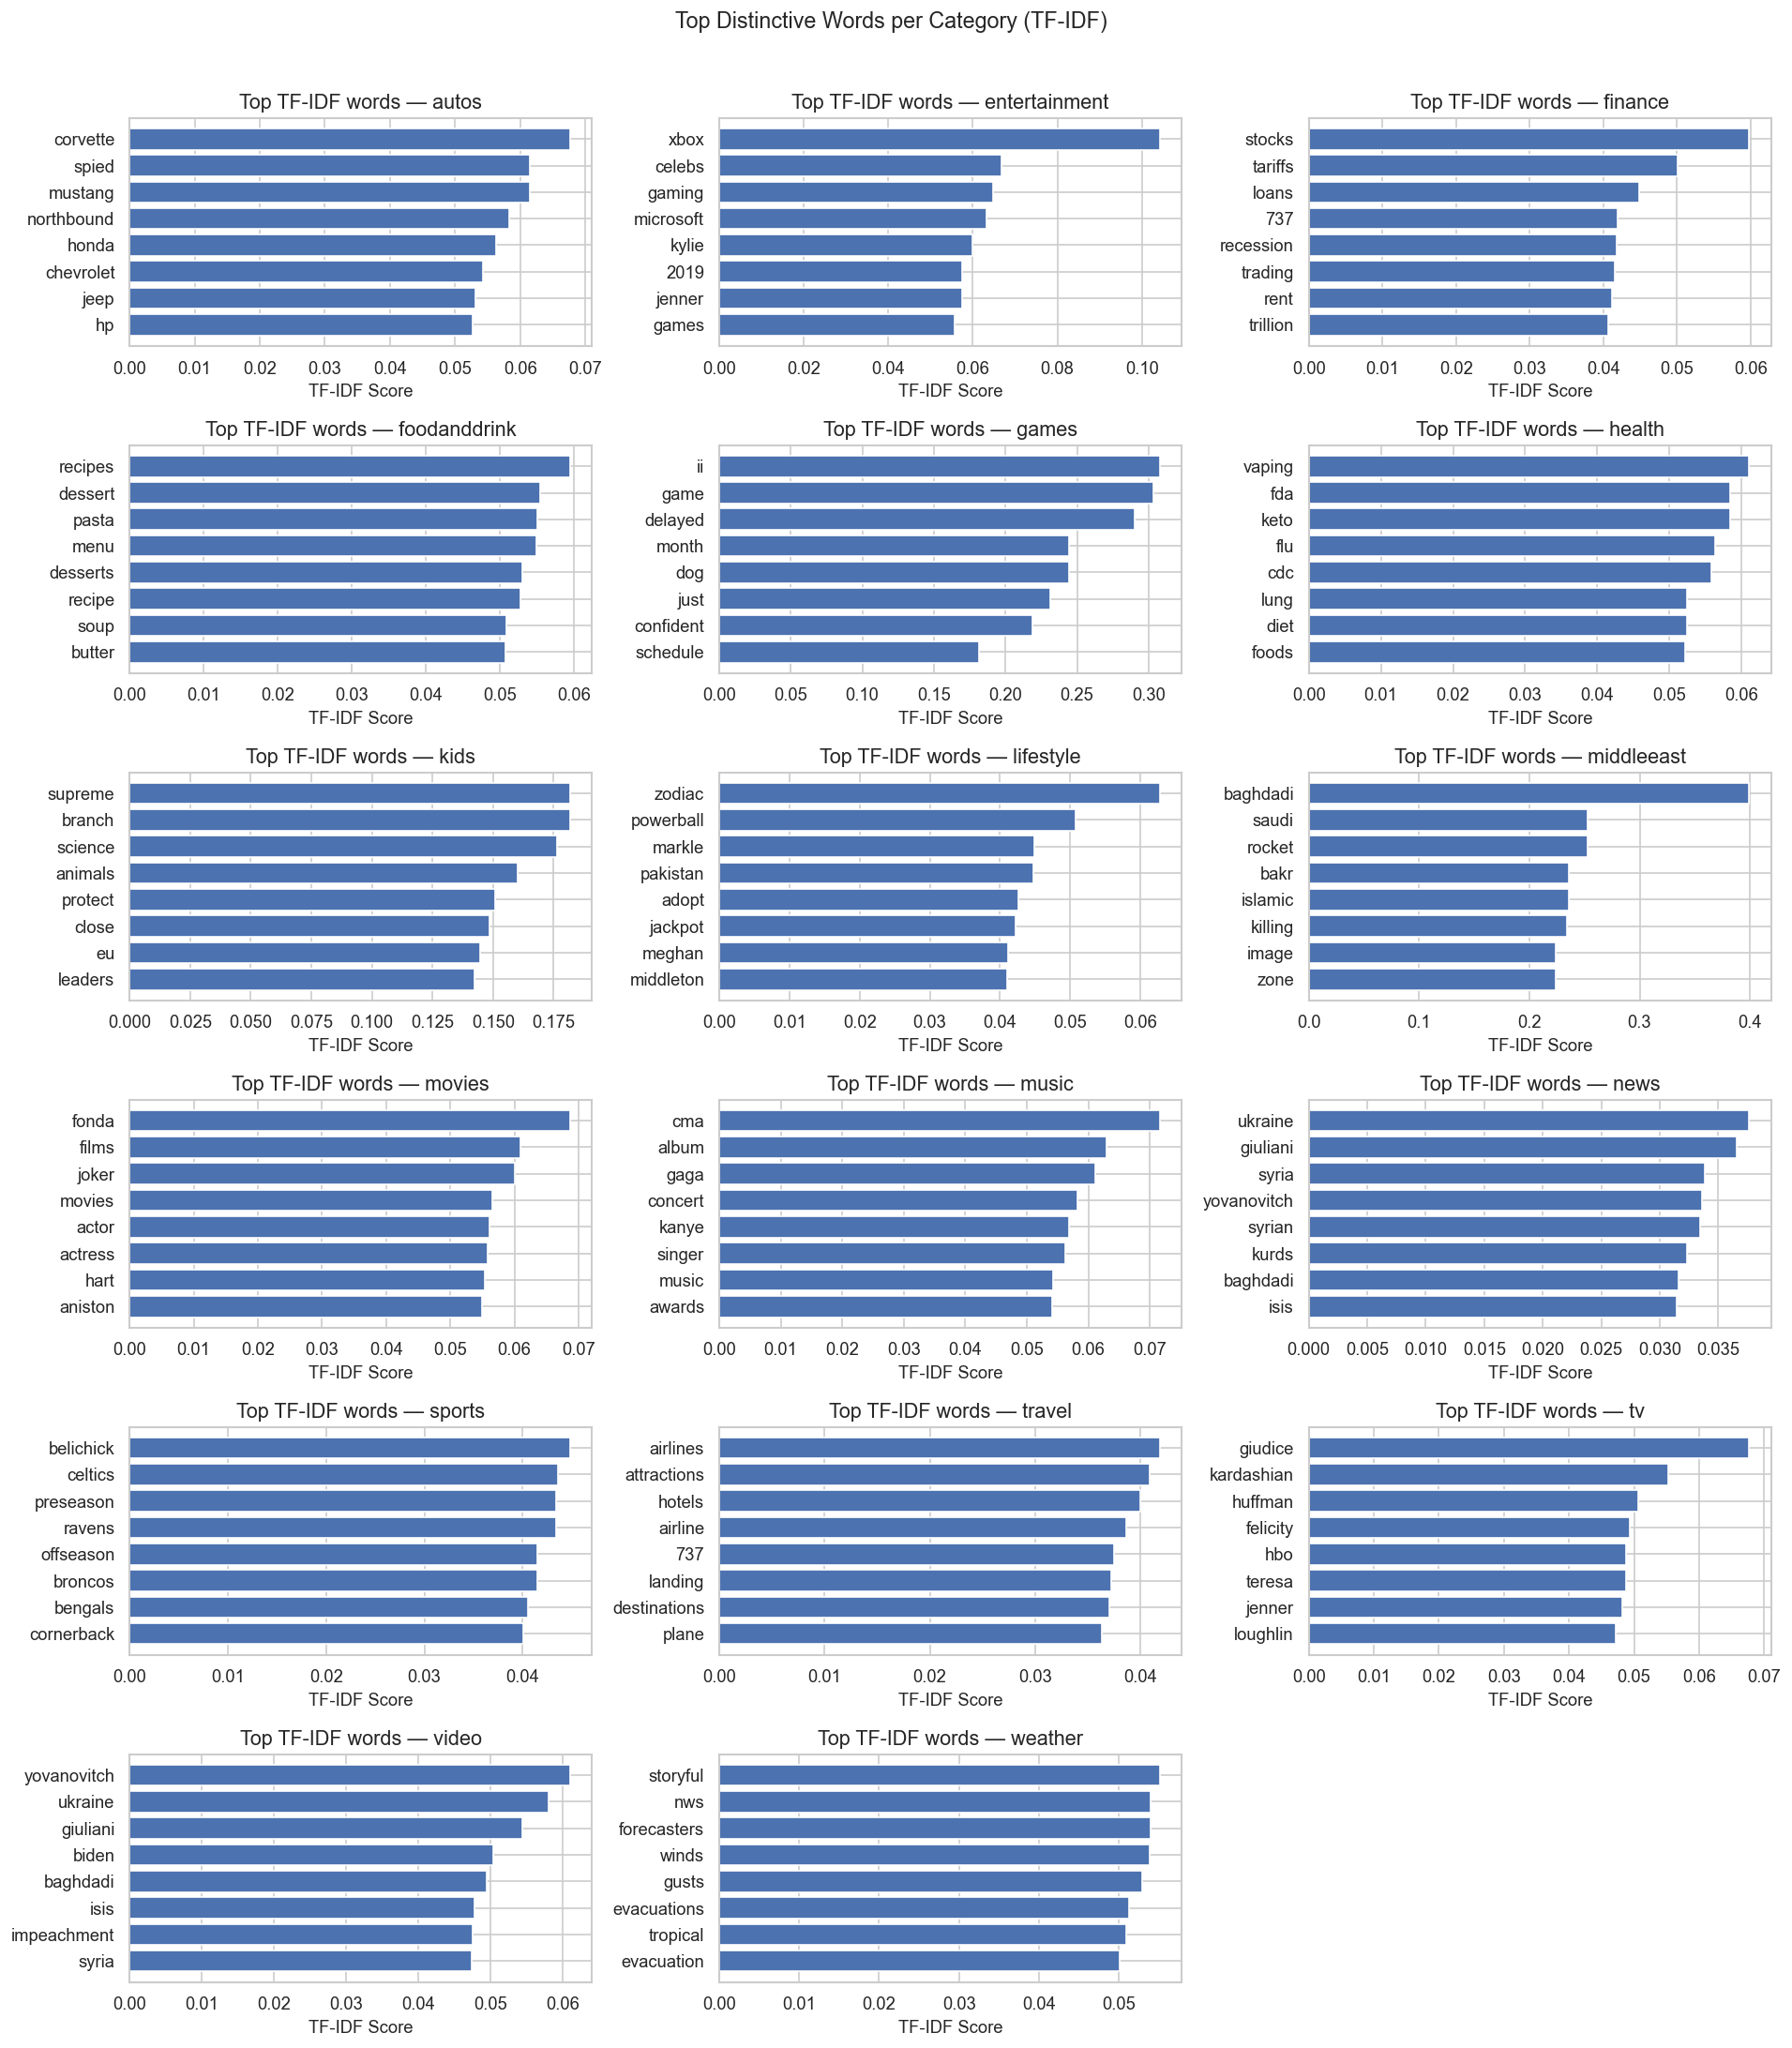

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer

news['text'] = news['title'].fillna('') + ' ' + news['abstract'].fillna('')

# One pseudo-document per category
cat_docs = news.groupby('category')['text'].apply(' '.join)

tfidf = TfidfVectorizer(max_features=5000, stop_words='english',
                        ngram_range=(1,1), sublinear_tf=True)
tfidf_mat = tfidf.fit_transform(cat_docs)
terms = tfidf.get_feature_names_out()

N_TOP = 8
n_cats = len(cat_docs)
cols = 3
rows = (n_cats + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 3))
axes = axes.flatten()

for i, cat in enumerate(cat_docs.index):
    row_arr = tfidf_mat[i].toarray().flatten()
    top_idx = row_arr.argsort()[-N_TOP:][::-1]
    top_words  = [terms[j] for j in top_idx]
    top_scores = [row_arr[j] for j in top_idx]
    axes[i].barh(top_words[::-1], top_scores[::-1], color=BLUE)
    axes[i].set_title(f'Top TF-IDF words — {cat}')
    axes[i].set_xlabel('TF-IDF Score')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Top Distinctive Words per Category (TF-IDF)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'A5_top_words_per_category.png'), bbox_inches='tight')
plt.show()

## A6. Entity Coverage

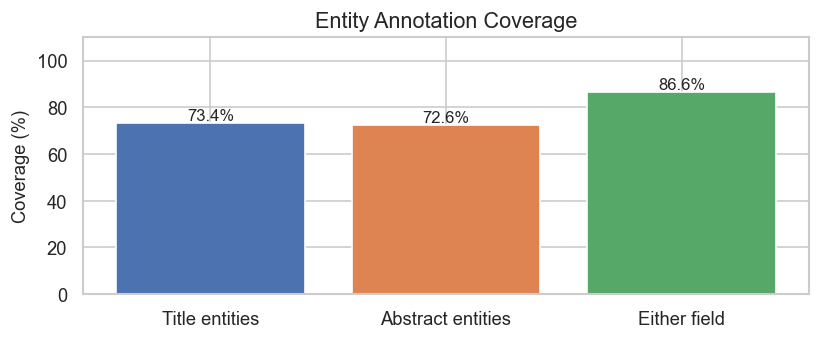

Entity type distribution (title_entities):
P    13347
O    13091
G    10008
U     3082
C     2759
N     1386
F     1354
W      813
S      725
E      637
M      492
V      455
B      407
L      400
H      388
J      236
K      121
Y       95
R       69
Q       18
A       16
I       11


In [19]:
def has_entity(s):
    try:
        return len(json.loads(s)) > 0 if pd.notna(s) else False
    except:
        return False

news['has_title_ent']    = news['title_entities'].apply(has_entity)
news['has_abstract_ent'] = news['abstract_entities'].apply(has_entity)

coverage = pd.Series({
    'Title entities'   : news['has_title_ent'].mean() * 100,
    'Abstract entities': news['has_abstract_ent'].mean() * 100,
    'Either field'     : (news['has_title_ent'] | news['has_abstract_ent']).mean() * 100,
})

fig, ax = plt.subplots(figsize=(7, 3))
bars = ax.bar(coverage.index, coverage.values, color=[BLUE, ORANGE, GREEN])
ax.set_ylabel('Coverage (%)')
ax.set_title('Entity Annotation Coverage')
ax.set_ylim(0, 110)
for bar, val in zip(bars, coverage.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'A6_entity_coverage.png'))
plt.show()

# Entity type distribution
all_entities = []
for s in news['title_entities'].dropna():
    try:
        for e in json.loads(s):
            all_entities.append(e.get('Type', 'Unknown'))
    except:
        pass

type_counts = pd.Series(Counter(all_entities)).sort_values(ascending=False)
print('Entity type distribution (title_entities):')
print(type_counts.to_string())

---
# Part B — behaviors.tsv Analysis

## B1. Basic Statistics

In [20]:
# Parse impressions into candidates + labels
def parse_impressions(imp_str):
    items = str(imp_str).split()
    news_ids = [x.rsplit('-',1)[0] for x in items]
    labels   = [int(x.rsplit('-',1)[1]) for x in items]
    return news_ids, labels

beh['n_candidates'] = beh['impressions'].apply(lambda x: len(str(x).split()))
beh['n_clicks']     = beh['impressions'].apply(
    lambda x: sum(1 for item in str(x).split() if item.endswith('-1')))
beh['history_len']  = beh['history'].apply(
    lambda x: len(str(x).split()) if pd.notna(x) else 0)
beh['has_history']  = beh['history'].notna() & (beh['history'].str.strip() != '')

print(f"Total impressions    : {len(beh):,}")
print(f"Unique users         : {beh['user_id'].nunique():,}")
print(f"Date range           : {beh['time'].min().date()} → {beh['time'].max().date()}")
print(f"Cold-start users     : {(~beh['has_history']).sum():,} ({(~beh['has_history']).mean()*100:.1f}%)")
print(f"Avg candidates/imp   : {beh['n_candidates'].mean():.1f}")
print(f"Avg clicks/imp       : {beh['n_clicks'].mean():.3f}")
print(f"Overall CTR          : {beh['n_clicks'].sum()/beh['n_candidates'].sum()*100:.2f}%")

Total impressions    : 73,152
Unique users         : 50,000
Date range           : 2019-11-15 → 2019-11-15
Cold-start users     : 2,214 (3.0%)
Avg candidates/imp   : 37.5
Avg clicks/imp       : 1.523
Overall CTR          : 4.06%


## B2. User Activity Distribution

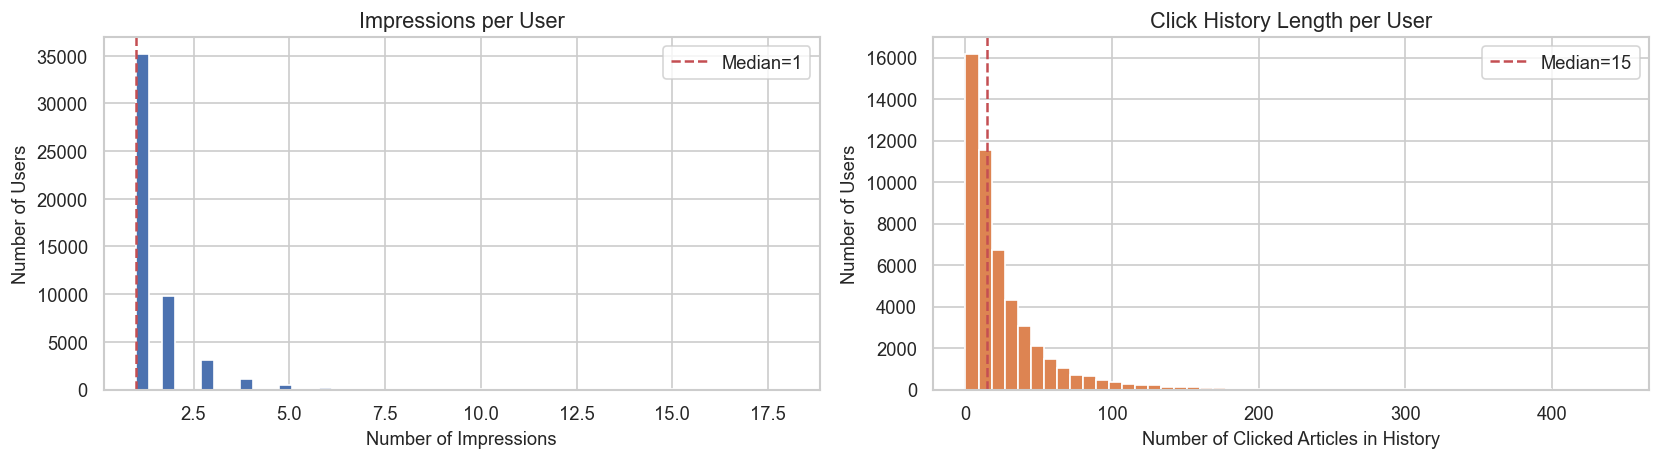

Impressions per user:
count    50000.00
mean         1.46
std          0.91
min          1.00
25%          1.00
50%          1.00
75%          2.00
max         18.00

History length per user:
count    50000.00
mean        25.52
std         31.19
min          0.00
25%          7.00
50%         15.00
75%         32.00
max        444.00


In [21]:
user_imp  = beh.groupby('user_id').size()
user_hist = beh.groupby('user_id')['history_len'].max()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Impressions per user
axes[0].hist(user_imp, bins=50, color=BLUE, edgecolor='white')
axes[0].axvline(user_imp.median(), color=RED, linestyle='--',
                label=f'Median={user_imp.median():.0f}')
axes[0].set_title('Impressions per User')
axes[0].set_xlabel('Number of Impressions')
axes[0].set_ylabel('Number of Users')
axes[0].legend()

# History length per user
axes[1].hist(user_hist, bins=50, color=ORANGE, edgecolor='white')
axes[1].axvline(user_hist.median(), color=RED, linestyle='--',
                label=f'Median={user_hist.median():.0f}')
axes[1].set_title('Click History Length per User')
axes[1].set_xlabel('Number of Clicked Articles in History')
axes[1].set_ylabel('Number of Users')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'B2_user_activity.png'))
plt.show()

print('Impressions per user:')
print(user_imp.describe().round(2).to_string())
print('\nHistory length per user:')
print(user_hist.describe().round(2).to_string())

## B3. Candidates per Impression & Click Distribution

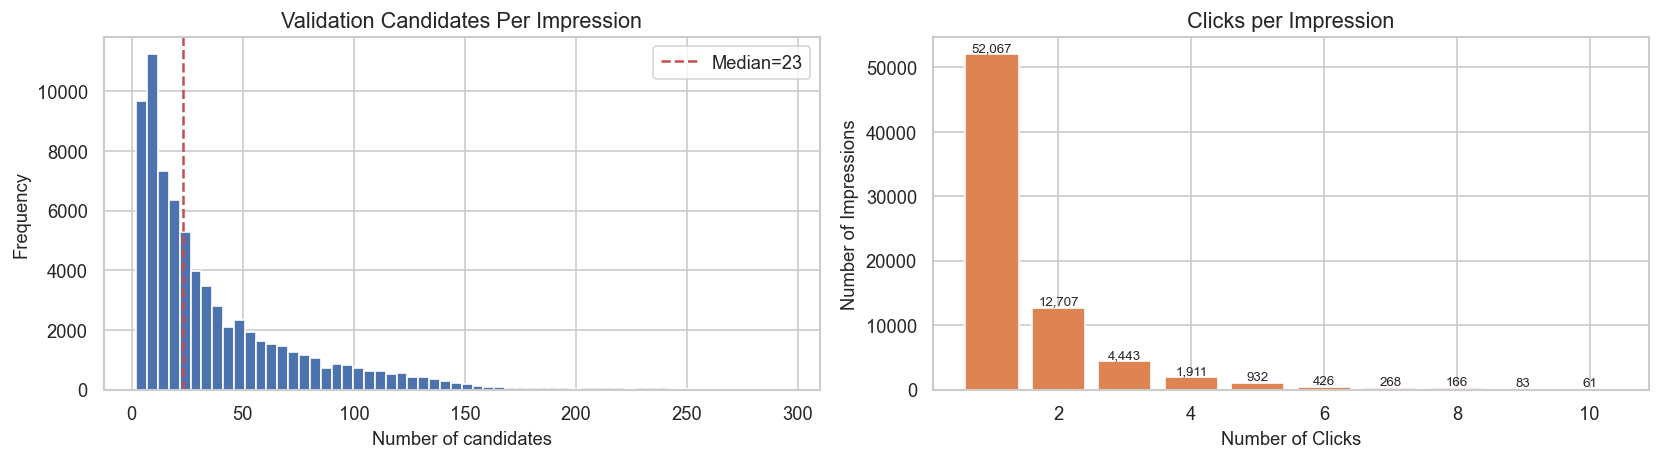

Candidates per impression:
count    73152.00
mean        37.47
std         39.54
min          2.00
25%         10.00
50%         23.00
75%         51.00
max        295.00


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Candidates per impression
axes[0].hist(beh['n_candidates'], bins=60, color=BLUE, edgecolor='white')
axes[0].axvline(beh['n_candidates'].median(), color=RED, linestyle='--',
                label=f'Median={beh["n_candidates"].median():.0f}')
axes[0].set_title('Validation Candidates Per Impression')
axes[0].set_xlabel('Number of candidates')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Clicks per impression
click_counts = beh['n_clicks'].value_counts().sort_index().head(10)
axes[1].bar(click_counts.index, click_counts.values, color=ORANGE, edgecolor='white')
axes[1].set_title('Clicks per Impression')
axes[1].set_xlabel('Number of Clicks')
axes[1].set_ylabel('Number of Impressions')
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'B3_candidates_and_clicks.png'))
plt.show()

print('Candidates per impression:')
print(beh['n_candidates'].describe().round(2).to_string())

## B4. Position Bias

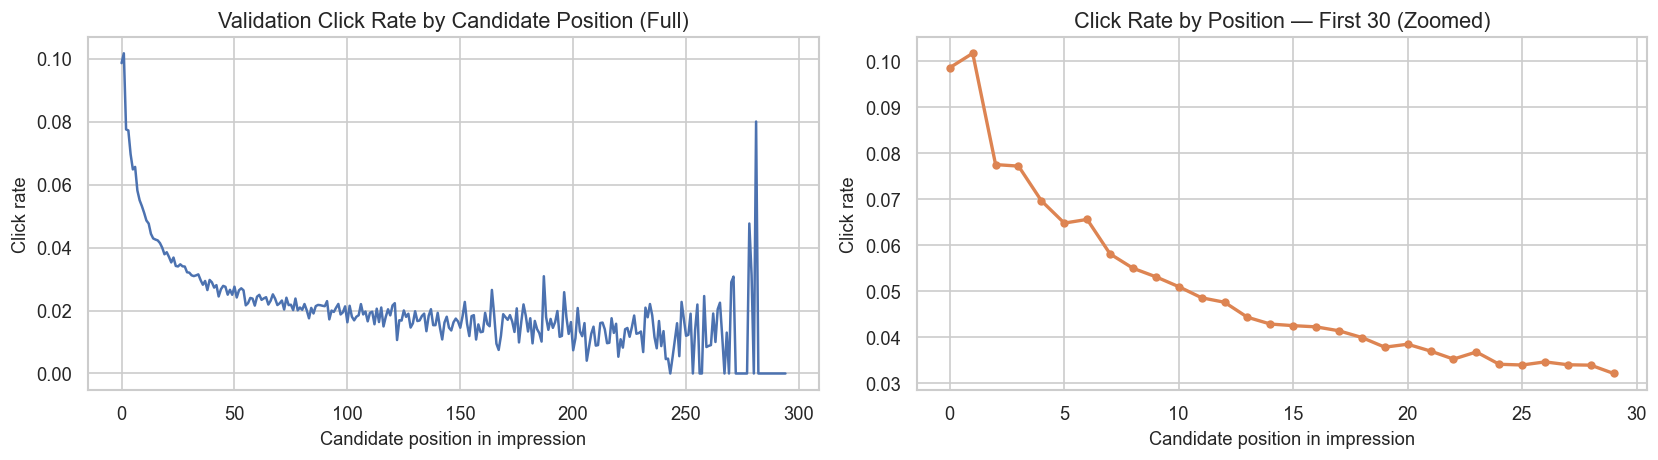

Click rate at first 5 positions:
position
0    0.0985
1    0.1017
2    0.0775
3    0.0772
4    0.0696

CTR drop: position 0 → position 9: 0.0985 → 0.0531


In [23]:
# Expand each impression to (position, label) pairs
pos_records = []
for _, row in beh.iterrows():
    for pos, item in enumerate(str(row['impressions']).split()):
        label = int(item.rsplit('-', 1)[1])
        pos_records.append({'position': pos, 'label': label})

pos_df = pd.DataFrame(pos_records)
pos_ctr = pos_df.groupby('position')['label'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Full range
axes[0].plot(pos_ctr.index, pos_ctr.values, color=BLUE, linewidth=1.5)
axes[0].set_title('Validation Click Rate by Candidate Position (Full)')
axes[0].set_xlabel('Candidate position in impression')
axes[0].set_ylabel('Click rate')

# Zoom in: first 30 positions
axes[1].plot(pos_ctr.index[:30], pos_ctr.values[:30],
             color=ORANGE, linewidth=2, marker='o', markersize=4)
axes[1].set_title('Click Rate by Position — First 30 (Zoomed)')
axes[1].set_xlabel('Candidate position in impression')
axes[1].set_ylabel('Click rate')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'B4_position_bias.png'))
plt.show()

print('Click rate at first 5 positions:')
print(pos_ctr.head(5).round(4).to_string())
print(f'\nCTR drop: position 0 → position 9:',
      f'{pos_ctr.iloc[0]:.4f} → {pos_ctr.iloc[9]:.4f}')

## B5. Temporal Analysis

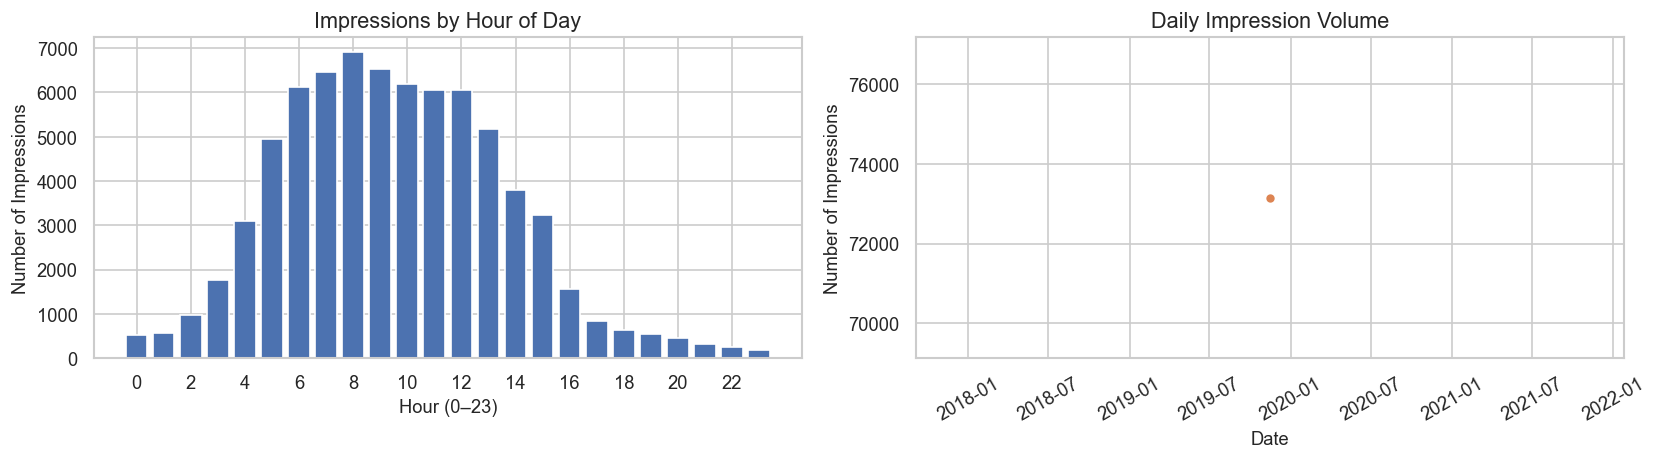

Peak hour: 8 (6,903 impressions)
Quietest hour: 23 (183 impressions)


In [24]:
beh['hour'] = beh['time'].dt.hour
beh['date'] = beh['time'].dt.date

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Hourly impression volume
hour_counts = beh.groupby('hour').size()
axes[0].bar(hour_counts.index, hour_counts.values, color=BLUE, edgecolor='white')
axes[0].set_title('Impressions by Hour of Day')
axes[0].set_xlabel('Hour (0–23)')
axes[0].set_ylabel('Number of Impressions')
axes[0].set_xticks(range(0, 24, 2))

# Daily impression volume
daily_counts = beh.groupby('date').size()
axes[1].plot(daily_counts.index, daily_counts.values,
             color=ORANGE, linewidth=2, marker='o', markersize=4)
axes[1].set_title('Daily Impression Volume')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Number of Impressions')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'B5_temporal.png'))
plt.show()

print('Peak hour:', hour_counts.idxmax(), f'({hour_counts.max():,} impressions)')
print('Quietest hour:', hour_counts.idxmin(), f'({hour_counts.min():,} impressions)')

---
# Part C — Joint Analysis

## C1. News Popularity (Click Count)

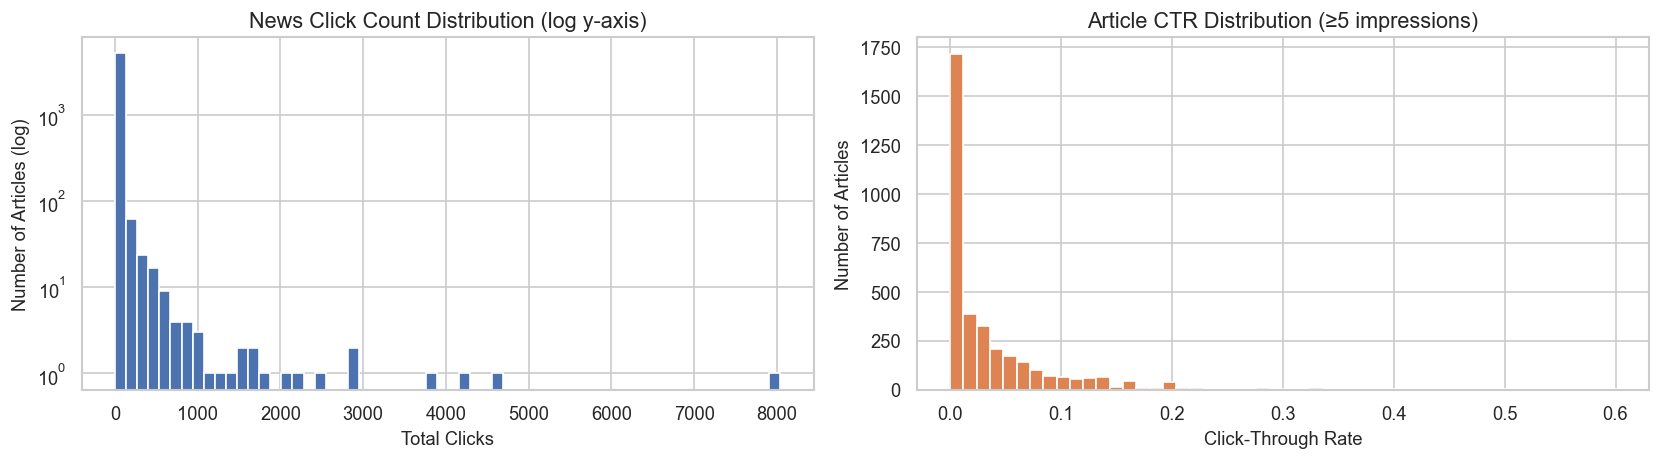

Articles never clicked  : 3,157 (58.8%)
Articles clicked ≥10x   : 654

Top 10 most clicked articles:
news_id     category  clicks  impressions      ctr                                                                                                     title
 N31958       sports    8042        47285 0.170075                                      Opinion: Colin Kaepernick is about to get what he deserves: a chance
 N36779         news    4688        36205 0.129485                             South Carolina teen gets life in prison for deadly elementary school shooting
  N5940    lifestyle    4191        39840 0.105196               Meghan Markle and Hillary Clinton Secretly Spent the Afternoon Together at Frogmore Cottage
 N20036    lifestyle    3826        34151 0.112032                                                                    30 Best Black Friday Deals from Costco
 N23513       sports    2900        20887 0.138842 This was uglier than a brawl. And Myles Garrett deserves suspen

In [25]:
# Expand all impressions to candidate-level
cand_records = []
for _, row in beh.iterrows():
    for item in str(row['impressions']).split():
        nid, label = item.rsplit('-', 1)
        cand_records.append({'news_id': nid, 'label': int(label)})

cand_df = pd.DataFrame(cand_records)
news_stats = cand_df.groupby('news_id').agg(
    impressions=('label', 'count'),
    clicks=('label', 'sum')
).reset_index()
news_stats['ctr'] = news_stats['clicks'] / news_stats['impressions']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Click count distribution (log scale)
axes[0].hist(news_stats['clicks'], bins=60, color=BLUE, edgecolor='white')
axes[0].set_yscale('log')
axes[0].set_title('News Click Count Distribution (log y-axis)')
axes[0].set_xlabel('Total Clicks')
axes[0].set_ylabel('Number of Articles (log)')

# CTR distribution
axes[1].hist(news_stats[news_stats['impressions'] >= 5]['ctr'],
             bins=50, color=ORANGE, edgecolor='white')
axes[1].set_title('Article CTR Distribution (≥5 impressions)')
axes[1].set_xlabel('Click-Through Rate')
axes[1].set_ylabel('Number of Articles')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'C1_news_popularity.png'))
plt.show()

never_clicked = (news_stats['clicks'] == 0).sum()
print(f'Articles never clicked  : {never_clicked:,} ({never_clicked/len(news_stats)*100:.1f}%)')
print(f'Articles clicked ≥10x   : {(news_stats["clicks"]>=10).sum():,}')
print('\nTop 10 most clicked articles:')
top10 = news_stats.nlargest(10, 'clicks').merge(news[['news_id','title','category']], on='news_id')
print(top10[['news_id','category','clicks','impressions','ctr','title']].to_string(index=False))

## C2. Click vs Non-Click — Category Distribution

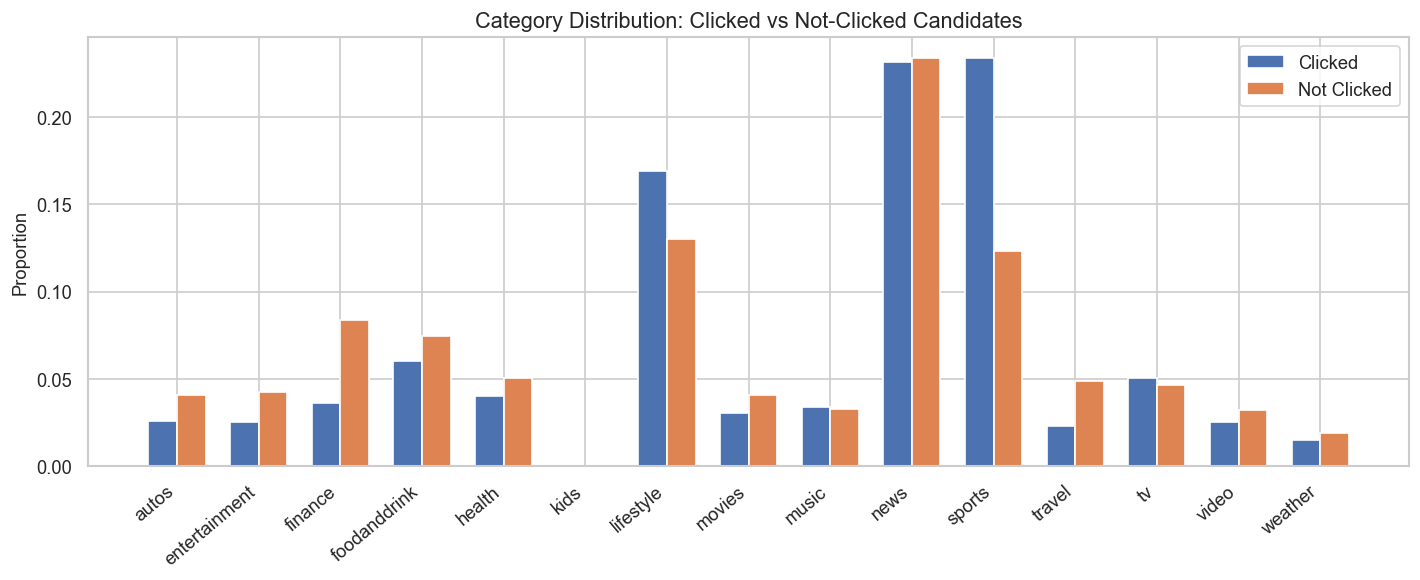

CTR by category:
category
sports           7.44
lifestyle        5.22
tv               4.41
music            4.23
news             4.02
foodanddrink     3.30
health           3.25
weather          3.23
video            3.21
movies           3.08
autos            2.58
entertainment    2.47
travel           1.95
finance          1.79
kids             0.00


In [26]:
cand_with_cat = cand_df.merge(news[['news_id','category']], on='news_id', how='left')

click_cat    = cand_with_cat[cand_with_cat['label']==1]['category'].value_counts(normalize=True)
no_click_cat = cand_with_cat[cand_with_cat['label']==0]['category'].value_counts(normalize=True)

compare = pd.DataFrame({'Clicked': click_cat, 'Not Clicked': no_click_cat}).fillna(0)

fig, ax = plt.subplots(figsize=(12, 5))
x = range(len(compare))
w = 0.35
ax.bar([i - w/2 for i in x], compare['Clicked'],    width=w, label='Clicked',     color=BLUE)
ax.bar([i + w/2 for i in x], compare['Not Clicked'], width=w, label='Not Clicked', color=ORANGE)
ax.set_xticks(list(x))
ax.set_xticklabels(compare.index, rotation=40, ha='right')
ax.set_ylabel('Proportion')
ax.set_title('Category Distribution: Clicked vs Not-Clicked Candidates')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'C2_category_click_vs_noclick.png'))
plt.show()

# Click-through rate per category
ctr_cat = cand_with_cat.groupby('category')['label'].mean().sort_values(ascending=False)
print('CTR by category:')
print((ctr_cat * 100).round(2).to_string())

## C3. Click vs Non-Click — Title Length

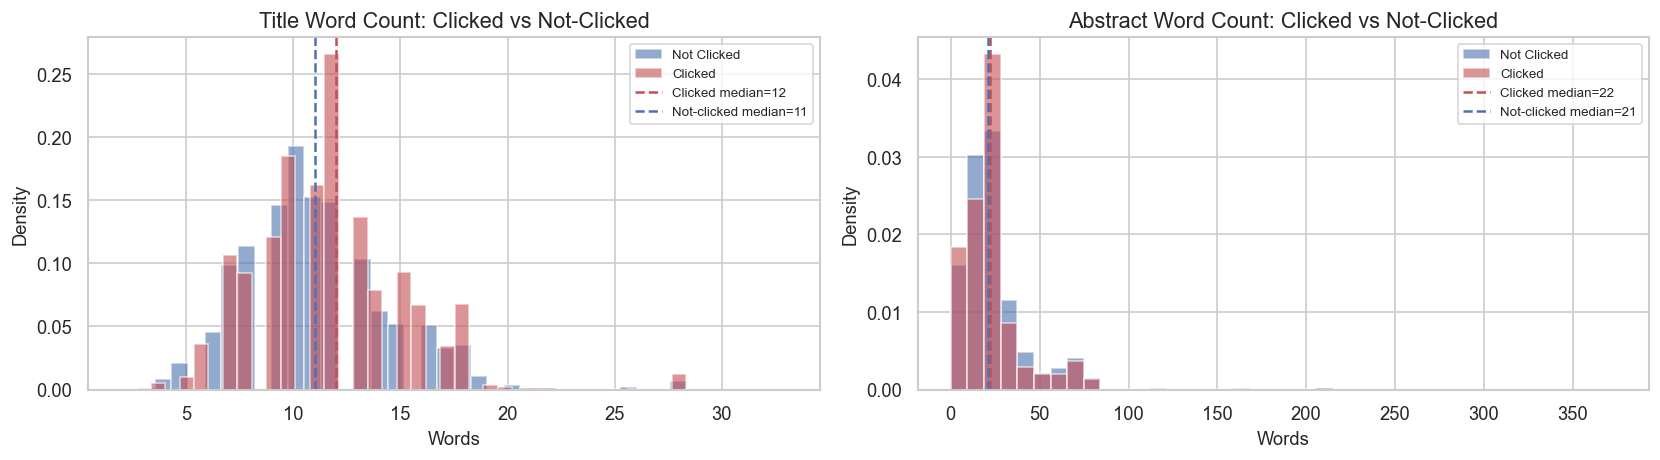

In [27]:
cand_with_len = cand_df.merge(news[['news_id','title_len','abstract_len']], on='news_id', how='left')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, col, label in zip(axes,
                          ['title_len', 'abstract_len'],
                          ['Title Word Count', 'Abstract Word Count']):
    clicked    = cand_with_len[cand_with_len['label']==1][col].dropna()
    not_clicked = cand_with_len[cand_with_len['label']==0][col].dropna()
    ax.hist(not_clicked, bins=40, alpha=0.6, label='Not Clicked',
            color=BLUE, density=True)
    ax.hist(clicked, bins=40, alpha=0.6, label='Clicked',
            color=RED, density=True)
    ax.axvline(clicked.median(), color=RED, linestyle='--',
               label=f'Clicked median={clicked.median():.0f}')
    ax.axvline(not_clicked.median(), color=BLUE, linestyle='--',
               label=f'Not-clicked median={not_clicked.median():.0f}')
    ax.set_title(f'{label}: Clicked vs Not-Clicked')
    ax.set_xlabel('Words')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'C3_length_click_vs_noclick.png'))
plt.show()

## C4. User Category Preference (Specialization vs Diversity)

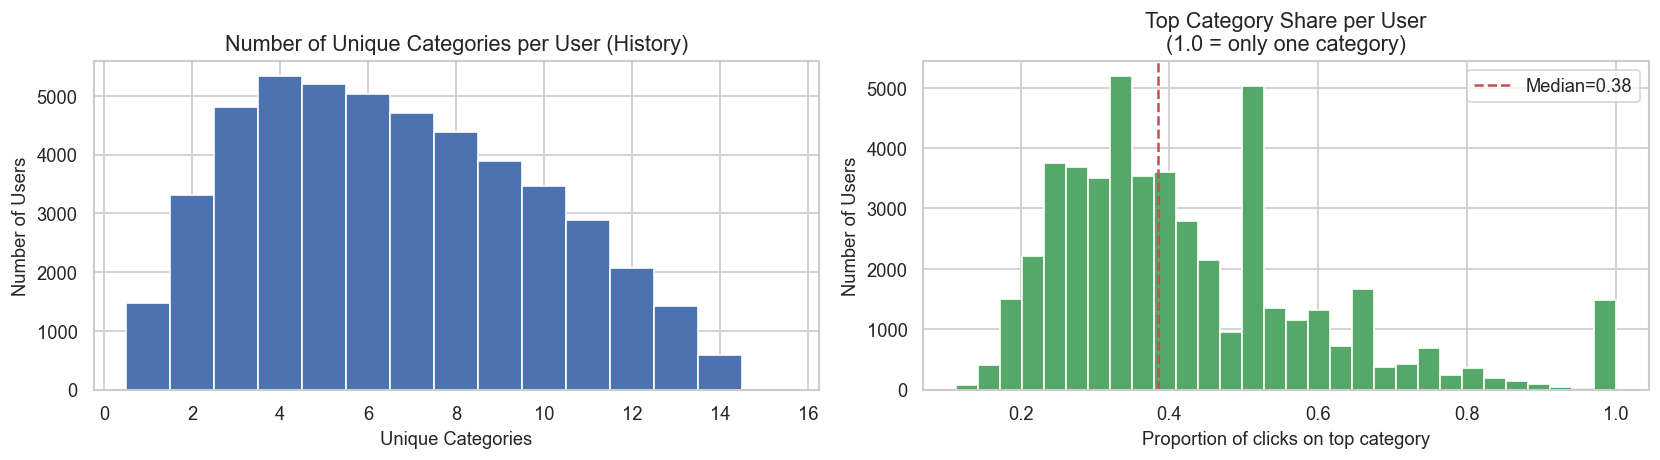

Users reading only 1 category : 1,475 (3.0%)
Median unique categories/user : 6
Median top-category share     : 0.38


In [28]:
# For each user, look at history articles and count unique categories
history_records = []
for _, row in beh.dropna(subset=['history']).iterrows():
    for nid in str(row['history']).split():
        history_records.append({'user_id': row['user_id'], 'news_id': nid})

hist_df = pd.DataFrame(history_records)
hist_df = hist_df.merge(news[['news_id','category']], on='news_id', how='left')

user_cat_diversity = hist_df.groupby('user_id')['category'].nunique()
user_top_cat_share = hist_df.groupby('user_id')['category'].apply(
    lambda x: x.value_counts(normalize=True).iloc[0])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(user_cat_diversity, bins=range(1, user_cat_diversity.max()+2),
             color=BLUE, edgecolor='white', align='left')
axes[0].set_title('Number of Unique Categories per User (History)')
axes[0].set_xlabel('Unique Categories')
axes[0].set_ylabel('Number of Users')

axes[1].hist(user_top_cat_share, bins=30, color=GREEN, edgecolor='white')
axes[1].axvline(user_top_cat_share.median(), color=RED, linestyle='--',
                label=f'Median={user_top_cat_share.median():.2f}')
axes[1].set_title('Top Category Share per User\n(1.0 = only one category)')
axes[1].set_xlabel('Proportion of clicks on top category')
axes[1].set_ylabel('Number of Users')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'C4_user_category_diversity.png'))
plt.show()

print(f"Users reading only 1 category : {(user_cat_diversity==1).sum():,} ({(user_cat_diversity==1).mean()*100:.1f}%)")
print(f"Median unique categories/user : {user_cat_diversity.median():.0f}")
print(f"Median top-category share     : {user_top_cat_share.median():.2f}")

---
## Summary

In [29]:
summary = {
    'total_articles'        : len(news),
    'total_impressions'     : len(beh),
    'unique_users'          : int(beh['user_id'].nunique()),
    'cold_start_pct'        : round((~beh['has_history']).mean()*100, 2),
    'overall_ctr_pct'       : round(beh['n_clicks'].sum()/beh['n_candidates'].sum()*100, 2),
    'avg_candidates_per_imp': round(beh['n_candidates'].mean(), 2),
    'avg_history_len'       : round(beh['history_len'].mean(), 2),
    'articles_never_clicked': int(never_clicked),
    'top_category'          : cat_counts.index[0],
    'date_range'            : f"{beh['time'].min().date()} to {beh['time'].max().date()}",
}

with open(os.path.join(OUTPUT_DIR, 'eda_summary.json'), 'w') as f:
    json.dump(summary, f, indent=2)

print('=== EDA Summary ===')
for k, v in summary.items():
    print(f'  {k:<30} {v}')
print(f'\nAll figures saved to: {OUTPUT_DIR}/')

=== EDA Summary ===
  total_articles                 42416
  total_impressions              73152
  unique_users                   50000
  cold_start_pct                 3.03
  overall_ctr_pct                4.06
  avg_candidates_per_imp         37.47
  avg_history_len                32.3
  articles_never_clicked         3157
  top_category                   news
  date_range                     2019-11-15 to 2019-11-15

All figures saved to: /Users/ningkezhang/Downloads/2026-MDSH-Submit/round1_baselines/eda_output/
